In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)

df = pd.read_csv("application_train.csv")   
data = df.copy()                            
data.head()



,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
print(f"shape of dataset: \n {data.shape}")
print(f"columns in dataset: \n {data.columns}")
print(f"duplicates in dataset: \n {data.duplicated().sum()}")
print(f"data types count in dataset: \n {data.dtypes.value_counts()}")

shape of dataset: 
 (307511, 122)
columns in dataset: 
 Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)
duplicates in dataset: 
 0
data types count in dataset: 
 float64    65
int64      41
object     16
Name: count, dtype: int64


In [3]:
#Missing values check
print(data.isnull().sum().sort_index(ascending=True))

AMT_ANNUITY                         12
AMT_CREDIT                           0
AMT_GOODS_PRICE                    278
AMT_INCOME_TOTAL                     0
AMT_REQ_CREDIT_BUREAU_DAY        41519
AMT_REQ_CREDIT_BUREAU_HOUR       41519
AMT_REQ_CREDIT_BUREAU_MON        41519
AMT_REQ_CREDIT_BUREAU_QRT        41519
AMT_REQ_CREDIT_BUREAU_WEEK       41519
AMT_REQ_CREDIT_BUREAU_YEAR       41519
APARTMENTS_AVG                  156061
APARTMENTS_MEDI                 156061
APARTMENTS_MODE                 156061
BASEMENTAREA_AVG                179943
BASEMENTAREA_MEDI               179943
BASEMENTAREA_MODE               179943
CNT_CHILDREN                         0
CNT_FAM_MEMBERS                      2
CODE_GENDER                          0
COMMONAREA_AVG                  214865
COMMONAREA_MEDI                 214865
COMMONAREA_MODE                 214865
DAYS_BIRTH                           0
DAYS_EMPLOYED                        0
DAYS_ID_PUBLISH                      0
DAYS_LAST_PHONE_CHANGE   

In [4]:
# finding Missing values %
missing = data.isnull().sum()
missing_percent = (missing / len(data)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

COMMONAREA_MEDI                 69.872297
COMMONAREA_AVG                  69.872297
COMMONAREA_MODE                 69.872297
NONLIVINGAPARTMENTS_MEDI        69.432963
NONLIVINGAPARTMENTS_MODE        69.432963
NONLIVINGAPARTMENTS_AVG         69.432963
FONDKAPREMONT_MODE              68.386172
LIVINGAPARTMENTS_MODE           68.354953
LIVINGAPARTMENTS_MEDI           68.354953
LIVINGAPARTMENTS_AVG            68.354953
FLOORSMIN_MODE                  67.848630
FLOORSMIN_MEDI                  67.848630
FLOORSMIN_AVG                   67.848630
YEARS_BUILD_MODE                66.497784
YEARS_BUILD_MEDI                66.497784
YEARS_BUILD_AVG                 66.497784
OWN_CAR_AGE                     65.990810
LANDAREA_AVG                    59.376738
LANDAREA_MEDI                   59.376738
LANDAREA_MODE                   59.376738
BASEMENTAREA_MEDI               58.515956
BASEMENTAREA_AVG                58.515956
BASEMENTAREA_MODE               58.515956
EXT_SOURCE_1                    56

In [5]:
# avg, mode, medi are same columns in dataset so we are removing columns which ha mode and medi in there name
cols_to_drop_redundant = [col for col in data.columns if col.endswith('_MODE') or col.endswith('_MEDI')]
print(cols_to_drop_redundant)
print(f"Total columns to drop: {len(cols_to_drop_redundant)}")

['APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
Total columns to drop: 33


In [6]:
# total columns after removing redundant columns
data = data.drop(cols_to_drop_redundant, axis=1)
print(data.shape)

(307511, 89)


In [7]:
# checking missing value % again after removing redundant columns
missing_percent = (data.isnull().sum() / len(data)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

COMMONAREA_AVG                 69.872297
NONLIVINGAPARTMENTS_AVG        69.432963
LIVINGAPARTMENTS_AVG           68.354953
FLOORSMIN_AVG                  67.848630
YEARS_BUILD_AVG                66.497784
OWN_CAR_AGE                    65.990810
LANDAREA_AVG                   59.376738
BASEMENTAREA_AVG               58.515956
EXT_SOURCE_1                   56.381073
NONLIVINGAREA_AVG              55.179164
ELEVATORS_AVG                  53.295980
APARTMENTS_AVG                 50.749729
ENTRANCES_AVG                  50.348768
LIVINGAREA_AVG                 50.193326
FLOORSMAX_AVG                  49.760822
YEARS_BEGINEXPLUATATION_AVG    48.781019
OCCUPATION_TYPE                31.345545
EXT_SOURCE_3                   19.825307
AMT_REQ_CREDIT_BUREAU_HOUR     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK     13.501631
AMT_REQ_CREDIT_BUREAU_DAY      13.501631
AMT_REQ_CREDIT_BUREAU_MON      13.501631
AMT_REQ_CREDIT_BUREAU_QRT      13.501631
AMT_REQ_CREDIT_BUREAU_YEAR     13.501631
NAME_TYPE_SUITE 

In [8]:
#Selecting Columns which has more than 40% missing value
threshold = 40
high_missing_cols = missing_percent[missing_percent > threshold].index.tolist()
print(high_missing_cols)
print(len(high_missing_cols))


['COMMONAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_AVG', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_AVG', 'BASEMENTAREA_AVG', 'EXT_SOURCE_1', 'NONLIVINGAREA_AVG', 'ELEVATORS_AVG', 'APARTMENTS_AVG', 'ENTRANCES_AVG', 'LIVINGAREA_AVG', 'FLOORSMAX_AVG', 'YEARS_BEGINEXPLUATATION_AVG']
16


In [9]:
#These columns have high missing values so we are check correlation with target columns
correlations = data[['COMMONAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_AVG', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_AVG', 'BASEMENTAREA_AVG', 'EXT_SOURCE_1', 'NONLIVINGAREA_AVG', 'ELEVATORS_AVG', 'APARTMENTS_AVG', 'ENTRANCES_AVG', 'LIVINGAREA_AVG', 'FLOORSMAX_AVG','YEARS_BEGINEXPLUATATION_AVG', 'TARGET']].corr()['TARGET'].sort_values()
print(correlations)

EXT_SOURCE_1                  -0.155317
FLOORSMAX_AVG                 -0.044003
ELEVATORS_AVG                 -0.034199
FLOORSMIN_AVG                 -0.033614
LIVINGAREA_AVG                -0.032997
APARTMENTS_AVG                -0.029498
LIVINGAPARTMENTS_AVG          -0.025031
BASEMENTAREA_AVG              -0.022746
YEARS_BUILD_AVG               -0.022149
ENTRANCES_AVG                 -0.019172
COMMONAREA_AVG                -0.018550
NONLIVINGAREA_AVG             -0.013578
LANDAREA_AVG                  -0.010885
YEARS_BEGINEXPLUATATION_AVG   -0.009728
NONLIVINGAPARTMENTS_AVG       -0.003176
OWN_CAR_AGE                    0.037612
TARGET                         1.000000
Name: TARGET, dtype: float64


In [ ]:

# these columns have lowest correlation so we are droping it
data = data.drop(['COMMONAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_AVG', 'YEARS_BUILD_AVG', 'LANDAREA_AVG', 'BASEMENTAREA_AVG', 'NONLIVINGAREA_AVG', 'ELEVATORS_AVG', 'APARTMENTS_AVG','ENTRANCES_AVG', 'LIVINGAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG'], axis=1)
print(data.shape)


(307511, 76)


In [11]:
# checking Missing value % again
missing_percent = (data.isnull().sum() / len(data)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

OWN_CAR_AGE                   65.990810
EXT_SOURCE_1                  56.381073
FLOORSMAX_AVG                 49.760822
OCCUPATION_TYPE               31.345545
EXT_SOURCE_3                  19.825307
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_HOUR    13.501631
NAME_TYPE_SUITE                0.420148
DEF_60_CNT_SOCIAL_CIRCLE       0.332021
OBS_30_CNT_SOCIAL_CIRCLE       0.332021
OBS_60_CNT_SOCIAL_CIRCLE       0.332021
DEF_30_CNT_SOCIAL_CIRCLE       0.332021
EXT_SOURCE_2                   0.214626
AMT_GOODS_PRICE                0.090403
AMT_ANNUITY                    0.003902
CNT_FAM_MEMBERS                0.000650
DAYS_LAST_PHONE_CHANGE         0.000325
dtype: float64


In [15]:
# Checking correlation of other missing value columns
missing_cols = ['EXT_SOURCE_1', 'FLOORSMAX_AVG', 'EXT_SOURCE_3', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'AMT_REQ_CREDIT_BUREAU_QRT','AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_WEEK','AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_2', 'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'CNT_FAM_MEMBERS', 'DAYS_LAST_PHONE_CHANGE']

correlations = data[missing_cols + ['TARGET']].corr()['TARGET'].sort_values()
print(correlations)

EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
FLOORSMAX_AVG                -0.044003
AMT_GOODS_PRICE              -0.039645
AMT_ANNUITY                  -0.012817
AMT_REQ_CREDIT_BUREAU_MON    -0.012462
AMT_REQ_CREDIT_BUREAU_QRT    -0.002022
AMT_REQ_CREDIT_BUREAU_WEEK    0.000788
AMT_REQ_CREDIT_BUREAU_HOUR    0.000930
AMT_REQ_CREDIT_BUREAU_DAY     0.002704
OBS_60_CNT_SOCIAL_CIRCLE      0.009022
OBS_30_CNT_SOCIAL_CIRCLE      0.009131
CNT_FAM_MEMBERS               0.009308
AMT_REQ_CREDIT_BUREAU_YEAR    0.019930
DEF_60_CNT_SOCIAL_CIRCLE      0.031276
DEF_30_CNT_SOCIAL_CIRCLE      0.032248
DAYS_LAST_PHONE_CHANGE        0.055218
TARGET                        1.000000
Name: TARGET, dtype: float64


In [16]:
# bucket analysis to fin non linear oattern o bureau inquiry
data['bureau_year_bucket'] = pd.cut(data['AMT_REQ_CREDIT_BUREAU_YEAR'], bins=[-1, 0, 2, 5, 100], labels=['0', '1-2', '3-5', '6+'])
print(data.groupby('bureau_year_bucket', observed=False)['TARGET'].mean())
data = data.drop(columns=['bureau_year_bucket'])  #removing temporary col

bureau_year_bucket
0      0.071350
1-2    0.076745
3-5    0.081167
6+     0.091761
Name: TARGET, dtype: float64


In [17]:
# drop this columns bcz it has no domain logic
data = data.drop(['CNT_FAM_MEMBERS'], axis=1)
print(data.shape)

(307511, 75)


In [19]:
# checking Flag/region columns with TARGET 
check_cols = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE','FLAG_PHONE', 'FLAG_EMAIL', 'REG_REGION_NOT_LIVE_REGION','REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION','REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY','REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REGION_POPULATION_RELATIVE']

correlations = data[check_cols + ['TARGET']].corr()['TARGET'].sort_values()
print(correlations)

REGION_POPULATION_RELATIVE    -0.037227
HOUR_APPR_PROCESS_START       -0.024166
FLAG_PHONE                    -0.023806
FLAG_EMAIL                    -0.001758
FLAG_CONT_MOBILE               0.000370
FLAG_MOBIL                     0.000534
LIVE_REGION_NOT_WORK_REGION    0.002819
REG_REGION_NOT_LIVE_REGION     0.005576
REG_REGION_NOT_WORK_REGION     0.006942
FLAG_WORK_PHONE                0.028524
LIVE_CITY_NOT_WORK_CITY        0.032518
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
TARGET                         1.000000
Name: TARGET, dtype: float64


In [20]:
#dropping HOUR_APPR_PROCESS_START bcz weak, also not combinable with anything
data = data.drop(['HOUR_APPR_PROCESS_START'], axis=1)
print(data.shape)

(307511, 74)


In [21]:
 #resevering columns that are weak but combinalble or Feature engineering
reserved_cols = ['FLAG_EMAIL', 'FLAG_MOBIL', 'FLAG_CONT_MOBILE','REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION','LIVE_REGION_NOT_WORK_REGION', 'FLAG_PHONE', 'FLAG_WORK_PHONE','FLAG_EMP_PHONE']

df_reserved = data[['SK_ID_CURR'] + reserved_cols].copy()   # adding sk_id columns so we can later combine
data = data.drop(columns=reserved_cols)                      #removing it from current data

print("data shape:", data.shape)
print("df_reserved shape:", df_reserved.shape)

data shape: (307511, 65)
df_reserved shape: (307511, 10)


In [ ]:
#checking missing value % so we can fill them 
#note: there are some columns with highest missing we don't remove bcz they are important
missing_percent = (data.isnull().sum() / len(data)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

OWN_CAR_AGE                   65.990810
EXT_SOURCE_1                  56.381073
FLOORSMAX_AVG                 49.760822
OCCUPATION_TYPE               31.345545
EXT_SOURCE_3                  19.825307
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
AMT_REQ_CREDIT_BUREAU_HOUR    13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
NAME_TYPE_SUITE                0.420148
DEF_30_CNT_SOCIAL_CIRCLE       0.332021
DEF_60_CNT_SOCIAL_CIRCLE       0.332021
OBS_60_CNT_SOCIAL_CIRCLE       0.332021
OBS_30_CNT_SOCIAL_CIRCLE       0.332021
EXT_SOURCE_2                   0.214626
AMT_GOODS_PRICE                0.090403
AMT_ANNUITY                    0.003902
DAYS_LAST_PHONE_CHANGE         0.000325
dtype: float64


### Filling Missing Values

In [23]:
cols_to_check = ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'FLOORSMAX_AVG', 'OCCUPATION_TYPE','EXT_SOURCE_3', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'AMT_REQ_CREDIT_BUREAU_HOUR','AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_DAY','NAME_TYPE_SUITE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE','OBS_60_CNT_SOCIAL_CIRCLE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_2','AMT_GOODS_PRICE', 'AMT_ANNUITY', 'DAYS_LAST_PHONE_CHANGE']

print(data[cols_to_check].head())
print(data[cols_to_check].dtypes)

   OWN_CAR_AGE  EXT_SOURCE_1  FLOORSMAX_AVG OCCUPATION_TYPE  EXT_SOURCE_3  \
0          NaN      0.083037         0.0833        Laborers      0.139376   
1          NaN      0.311267         0.2917      Core staff           NaN   
2         26.0           NaN            NaN        Laborers      0.729567   
3          NaN           NaN            NaN        Laborers           NaN   
4          NaN           NaN            NaN      Core staff           NaN   

   AMT_REQ_CREDIT_BUREAU_YEAR  AMT_REQ_CREDIT_BUREAU_HOUR  \
0                         1.0                         0.0   
1                         0.0                         0.0   
2                         0.0                         0.0   
3                         NaN                         NaN   
4                         0.0                         0.0   

   AMT_REQ_CREDIT_BUREAU_QRT  AMT_REQ_CREDIT_BUREAU_MON  \
0                        0.0                        0.0   
1                        0.0                        

In [24]:
#statistical summary of missing value columns to fill them
print(data[cols_to_check].describe(include='all'))

          OWN_CAR_AGE   EXT_SOURCE_1  FLOORSMAX_AVG OCCUPATION_TYPE  \
count   104582.000000  134133.000000  154491.000000          211120   
unique            NaN            NaN            NaN              18   
top               NaN            NaN            NaN        Laborers   
freq              NaN            NaN            NaN           55186   
mean        12.061091       0.502130       0.226282             NaN   
std         11.944812       0.211062       0.144641             NaN   
min          0.000000       0.014568       0.000000             NaN   
25%          5.000000       0.334007       0.166700             NaN   
50%          9.000000       0.505998       0.166700             NaN   
75%         15.000000       0.675053       0.333300             NaN   
max         91.000000       0.962693       1.000000             NaN   

         EXT_SOURCE_3  AMT_REQ_CREDIT_BUREAU_YEAR  AMT_REQ_CREDIT_BUREAU_HOUR  \
count   246546.000000               265992.000000               26

In [25]:
#filling occupation column with unaccompanied bcz its highest in freq
data['NAME_TYPE_SUITE'] = data['NAME_TYPE_SUITE'].fillna('Unaccompanied')

In [26]:
#filling occupation column with unknow
data['OCCUPATION_TYPE'] = data['OCCUPATION_TYPE'].fillna('Unknown')

In [27]:
#filling these columns with 0
bureau_cols = ['AMT_REQ_CREDIT_BUREAU_YEAR', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_DAY']

data[bureau_cols] = data[bureau_cols].fillna(0)

In [28]:
#filling these columns with 0
social_cols = ['DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'OBS_30_CNT_SOCIAL_CIRCLE']

data[social_cols] = data[social_cols].fillna(0)

In [29]:
#deciding which col to fill with mean or median
cols_check = ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 
              'FLOORSMAX_AVG', 'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'DAYS_LAST_PHONE_CHANGE']

for col in cols_check:
    print(f"{col}: mean={data[col].mean():.2f}, median={data[col].median():.2f}")

OWN_CAR_AGE: mean=12.06, median=9.00
EXT_SOURCE_1: mean=0.50, median=0.51
EXT_SOURCE_2: mean=0.51, median=0.57
EXT_SOURCE_3: mean=0.51, median=0.54
FLOORSMAX_AVG: mean=0.23, median=0.17
AMT_GOODS_PRICE: mean=538396.21, median=450000.00
AMT_ANNUITY: mean=27108.57, median=24903.00
DAYS_LAST_PHONE_CHANGE: mean=-962.86, median=-757.00


In [30]:
#filing with median
median_fill_cols = ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 
                     'FLOORSMAX_AVG', 'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'DAYS_LAST_PHONE_CHANGE']

for col in median_fill_cols:
    data[col] = data[col].fillna(data[col].median())

In [31]:
data.isnull().sum()

SK_ID_CURR                     0
TARGET                         0
NAME_CONTRACT_TYPE             0
CODE_GENDER                    0
FLAG_OWN_CAR                   0
FLAG_OWN_REALTY                0
CNT_CHILDREN                   0
AMT_INCOME_TOTAL               0
AMT_CREDIT                     0
AMT_ANNUITY                    0
AMT_GOODS_PRICE                0
NAME_TYPE_SUITE                0
NAME_INCOME_TYPE               0
NAME_EDUCATION_TYPE            0
NAME_FAMILY_STATUS             0
NAME_HOUSING_TYPE              0
REGION_POPULATION_RELATIVE     0
DAYS_BIRTH                     0
DAYS_EMPLOYED                  0
DAYS_REGISTRATION              0
DAYS_ID_PUBLISH                0
OWN_CAR_AGE                    0
OCCUPATION_TYPE                0
REGION_RATING_CLIENT           0
REGION_RATING_CLIENT_W_CITY    0
WEEKDAY_APPR_PROCESS_START     0
REG_CITY_NOT_LIVE_CITY         0
REG_CITY_NOT_WORK_CITY         0
LIVE_CITY_NOT_WORK_CITY        0
ORGANIZATION_TYPE              0
EXT_SOURCE

### EDA (Exploratory data analysis)

In [32]:
#selecting columns that fit for visaulization
#finding flag document to drop it from new df bcz they are useless for visulaization
flag_doc_cols = [col for col in data.columns if col.startswith('FLAG_DOCUMENT')]
print(flag_doc_cols)
print(len(flag_doc_cols))

# new EDA df without lag columns
data_eda = data.drop(columns=flag_doc_cols)
print(data_eda.shape)

['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']
20
(307511, 45)


In [33]:
print(data_eda.columns.tolist())
print(len(data_eda.columns))

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'OCCUPATION_TYPE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'FLOORSMAX_AVG', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']
45


In [34]:
data.dtypes.value_counts()

int64      31
float64    22
object     12
Name: count, dtype: int64

In [35]:
#important categorical columns and numerical columns for visualization

num_col = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "DAYS_BIRTH", "DAYS_EMPLOYED", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "CNT_CHILDREN"]

cat_col = ["NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "NAME_TYPE_SUITE", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE"]

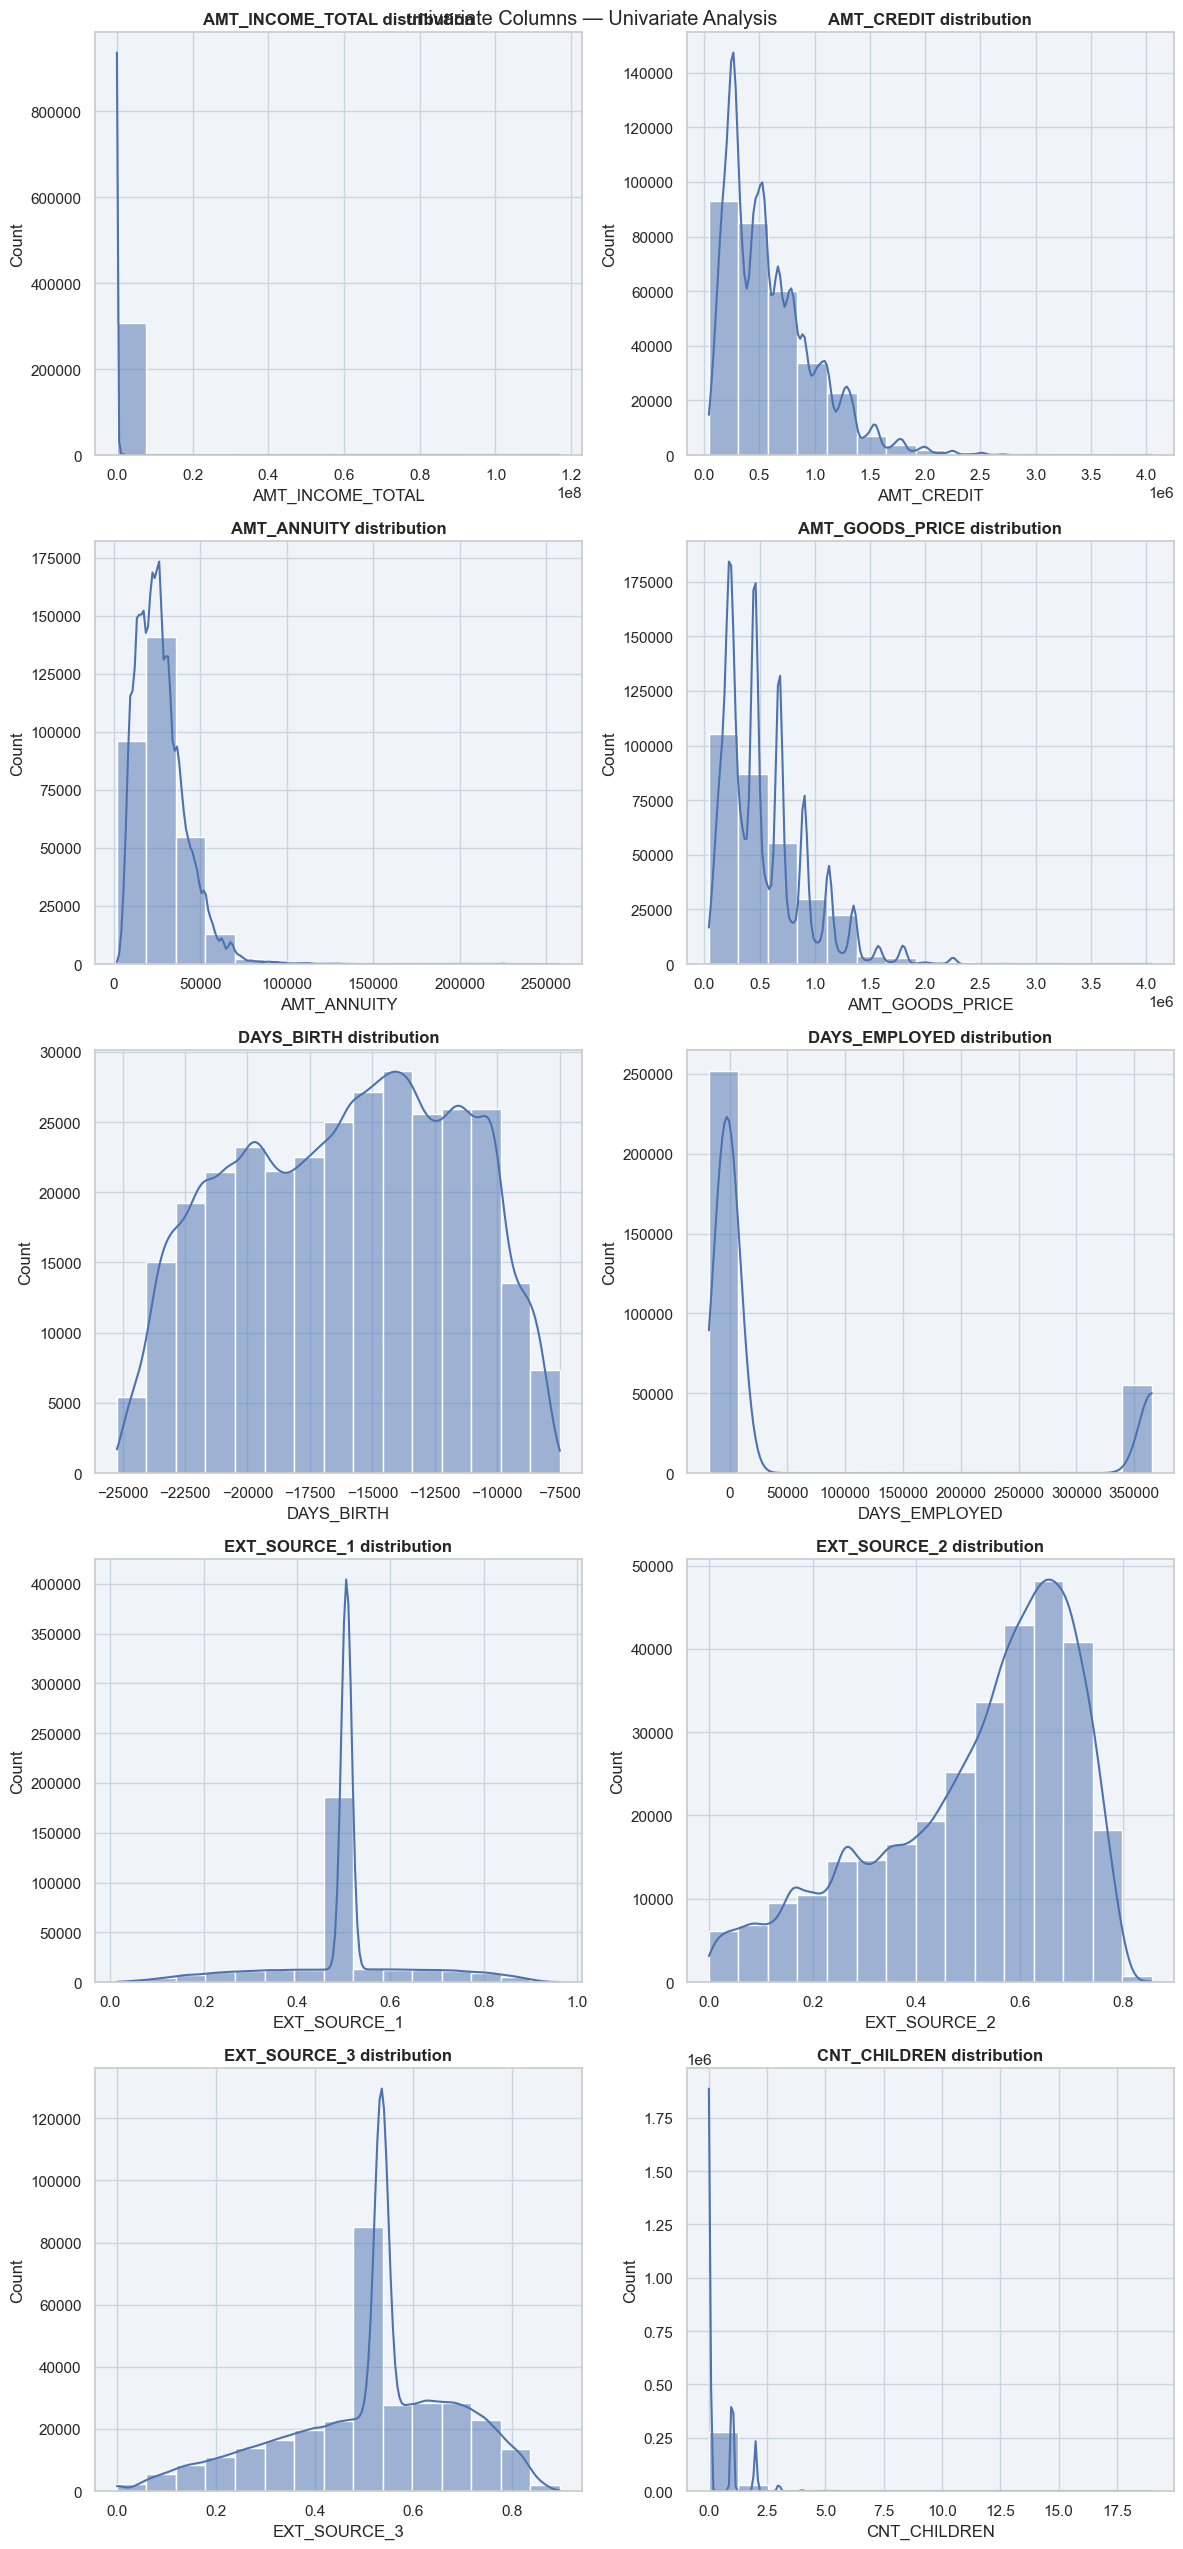

In [41]:
#univariate analysis of numerical columns 

sns.set_theme(style="whitegrid", rc={
        "axes.facecolor": "#f0f4f8",  
        "grid.color": "#cbd5e1"       
    })


fig, axes = plt.subplots(5, 2, figsize=(12,26))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.histplot(data=data_eda, x=col, kde=True, ax = axes[i], bins=15)
    axes[i].set_title(f"{col} distribution", weight='bold')

plt.suptitle("univariate Columns — Univariate Analysis")
plt.tight_layout()
plt.show()

#### Observation:
Most amount-related columns (AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE) are right-skewed, with values concentrated on the lower end and a long tail of high-value outliers extending out to their respective maximums. DAYS_BIRTH (stored as negative days from birth) is roughly symmetric/uniform, spread evenly across the range with a slight concentration corresponding to customers aged ~28-48. DAYS_EMPLOYED shows a bimodal pattern — most values cluster near 0 (recently employed), while a separate cluster sits around 350,000, which is a known placeholder-error value in this dataset rather than real employment data, to be fixed during Feature Engineering. EXT_SOURCE_1 and EXT_SOURCE_3 both show an artificial spike at 0.5, caused by median imputation of missing values rather than a natural distribution shape; EXT_SOURCE_2 (which had far fewer missing values) shows a genuine left-skew, concentrated between 0.6-0.7. Finally, CNT_CHILDREN is heavily right-skewed, with most customers having 0-1 children and rare outliers up to 17+.

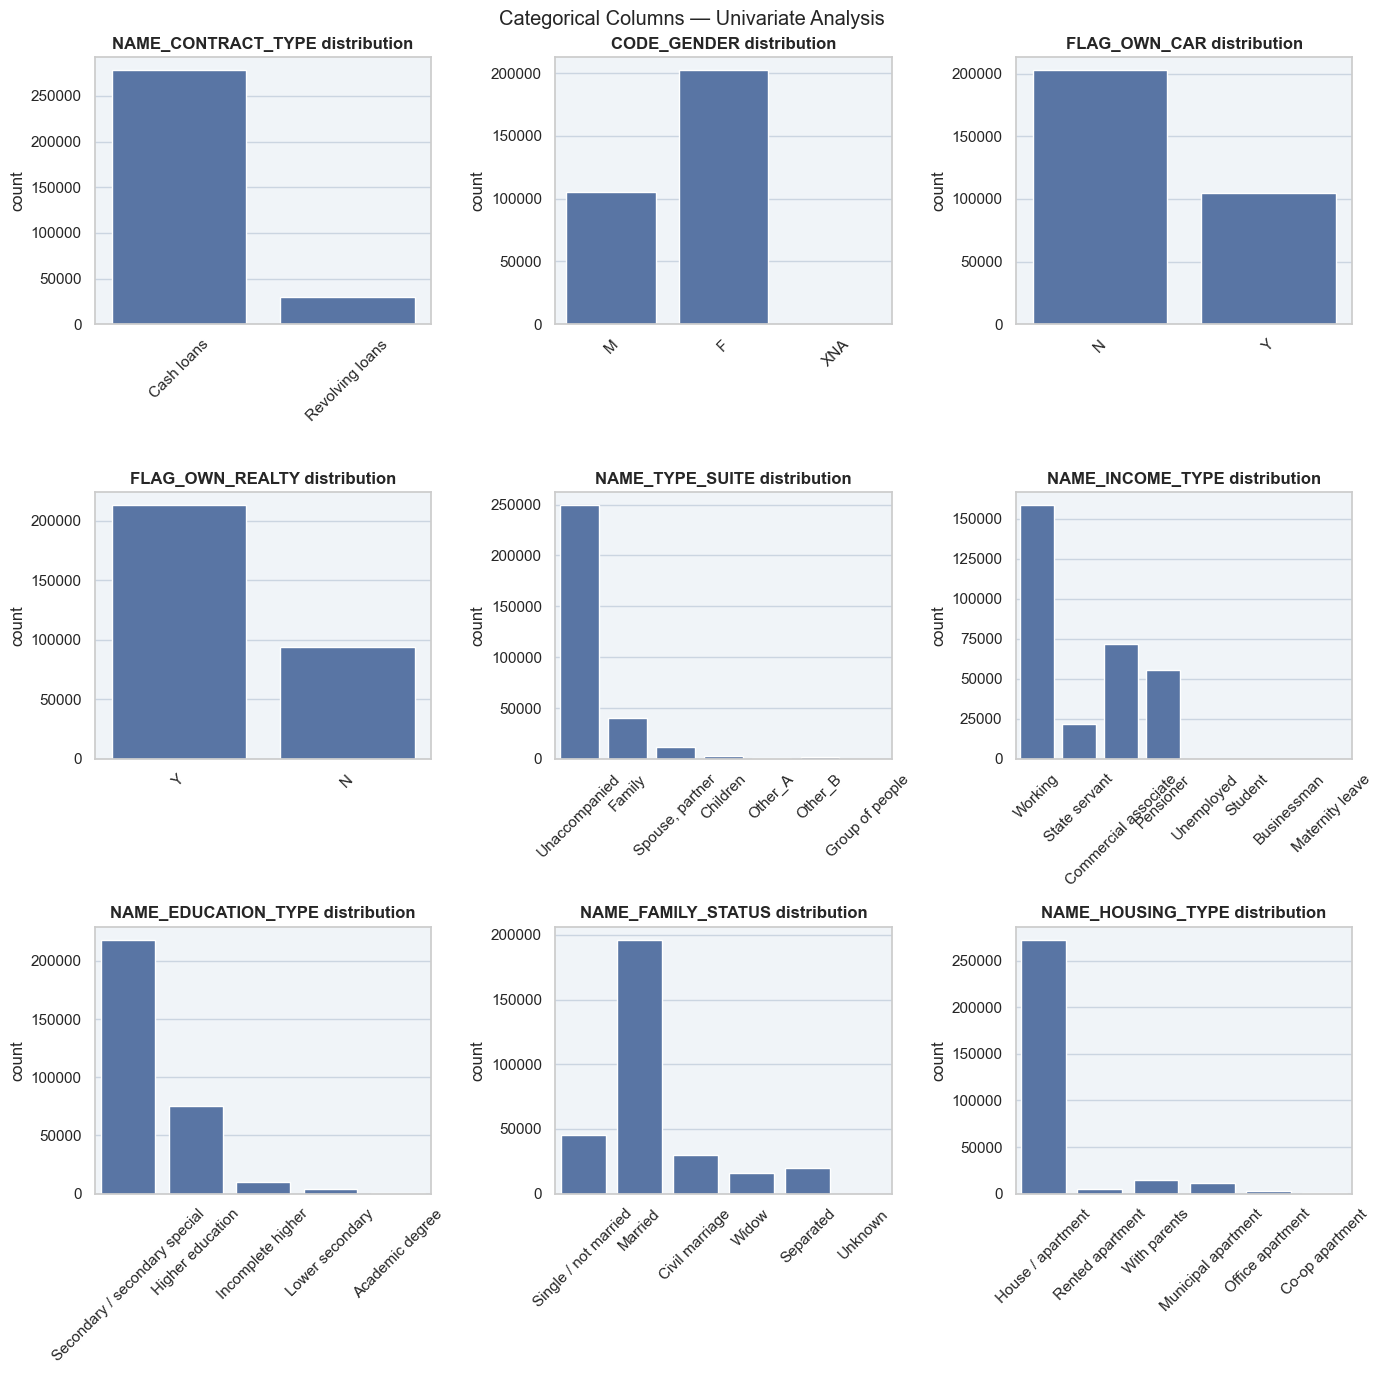

In [43]:
# Univariate analysis of categorical columns
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.countplot(data=data_eda, x=col, ax=axes[i])
    axes[i].set_title(f"{col} distribution", weight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel("")



plt.suptitle("Categorical Columns — Univariate Analysis")
plt.tight_layout()
plt.show()

#### Observation:
Most categorical columns are dominated by a single category: "Cash loans" outnumber "Revolving loans" by ~10x, "Unaccompanied" dominates type-suite, "Working" leads income type (with "Commercial associate" at roughly half its count), "Secondary/secondary special" dominates education (followed distantly by "Higher education"), "Married" more than doubles any other family status, and "House/apartment" overwhelmingly dominates housing type. For demographics, female applicants are roughly double the male applicants, with a negligible "XNA" category likely reflecting a data-entry anomaly. Ownership patterns are more balanced — slightly more customers don't own a car than do, while roughly twice as many customers own realty as don't.

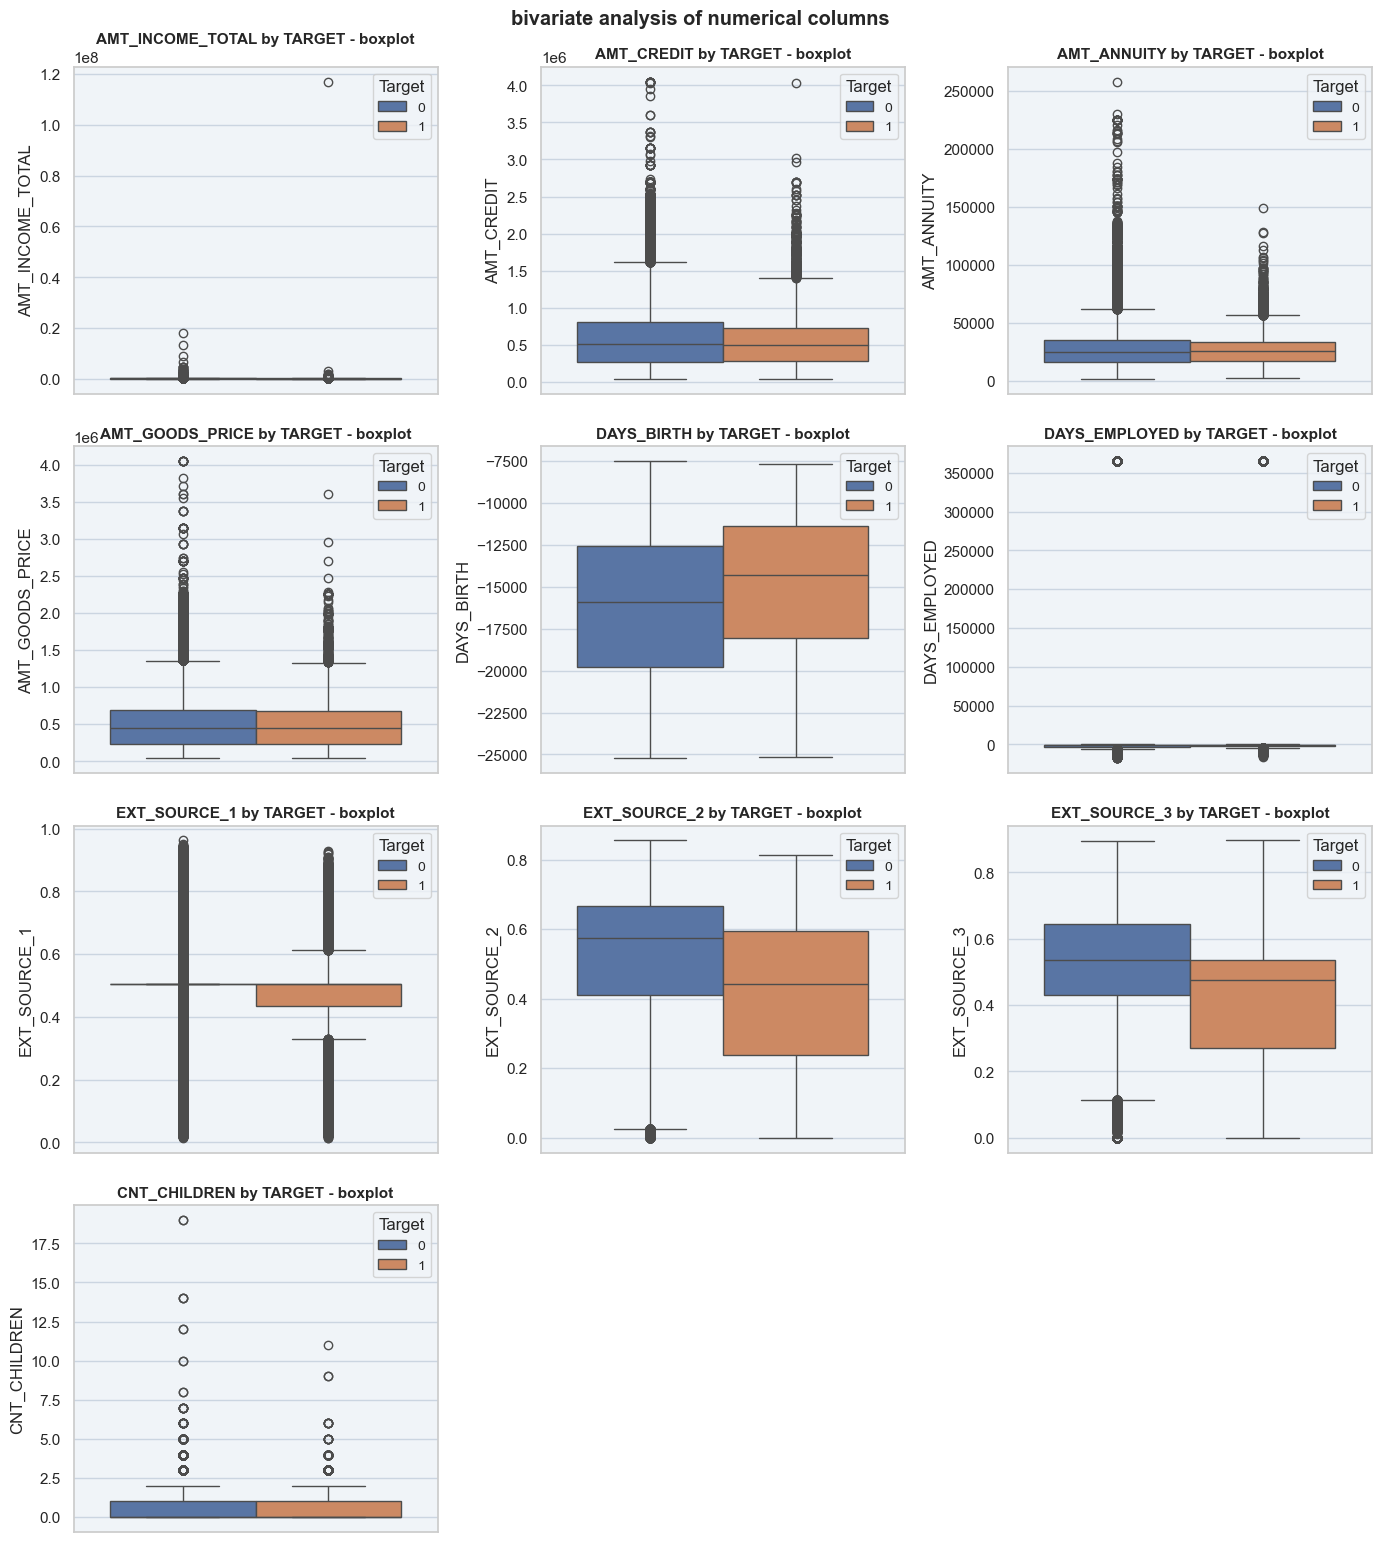

In [44]:
#bivariate analysis of numerical columns


fig, axes = plt.subplots(4, 3, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.boxplot(data=data_eda, y=col, hue="TARGET", ax=axes[i])
    axes[i].set_title(f"{col} by TARGET - boxplot", fontsize=11, weight='bold')
    axes[i].legend(loc="upper right", fontsize="small", title="Target")

plt.suptitle("bivariate analysis of numerical columns", weight='bold')
plt.tight_layout()
axes[10].set_visible(False)
axes[11].set_visible(False)
plt.show()

#### Observation:
For income and loan-related columns (AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE), the median values for both defaulters and non-defaulters are very close, so they do not look like strong individual predictors however, non-defaulters show slightly more high value outliers (bigger loans, larger purchases), which likely points to their stronger financial capacity. DAYS_BIRTH (recorded in negative days, meaning less negative equals a younger customer) shows a clear pattern: the median age of defaulters is lower than that of non-defaulters meaning younger customers tend to default more, which makes logical sense due to lower financial stability and less experience. In DAYS_EMPLOYED, most values are close to 0 (representing new or low-experience employees), but there are two extreme outliers around 350,000 that are actually a known bug in the data (a placeholder error value) rather than real employment duration this will need to be fixed during Feature Engineering. The strongest signal comes from EXT_SOURCE_2 and EXT_SOURCE_3, in both columns, non-defaulters clearly have a higher median score than defaulters, making them the most reliable predictors in this dataset (just as the correlation analysis confirmed). There is also a small difference in EXT_SOURCE_1, but its distribution is distorted by an artificial spike at 0.5, which is the result of using median imputation to fill missing values. For CNT_CHILDREN, both groups look almost identical, showing no meaningful difference at all.

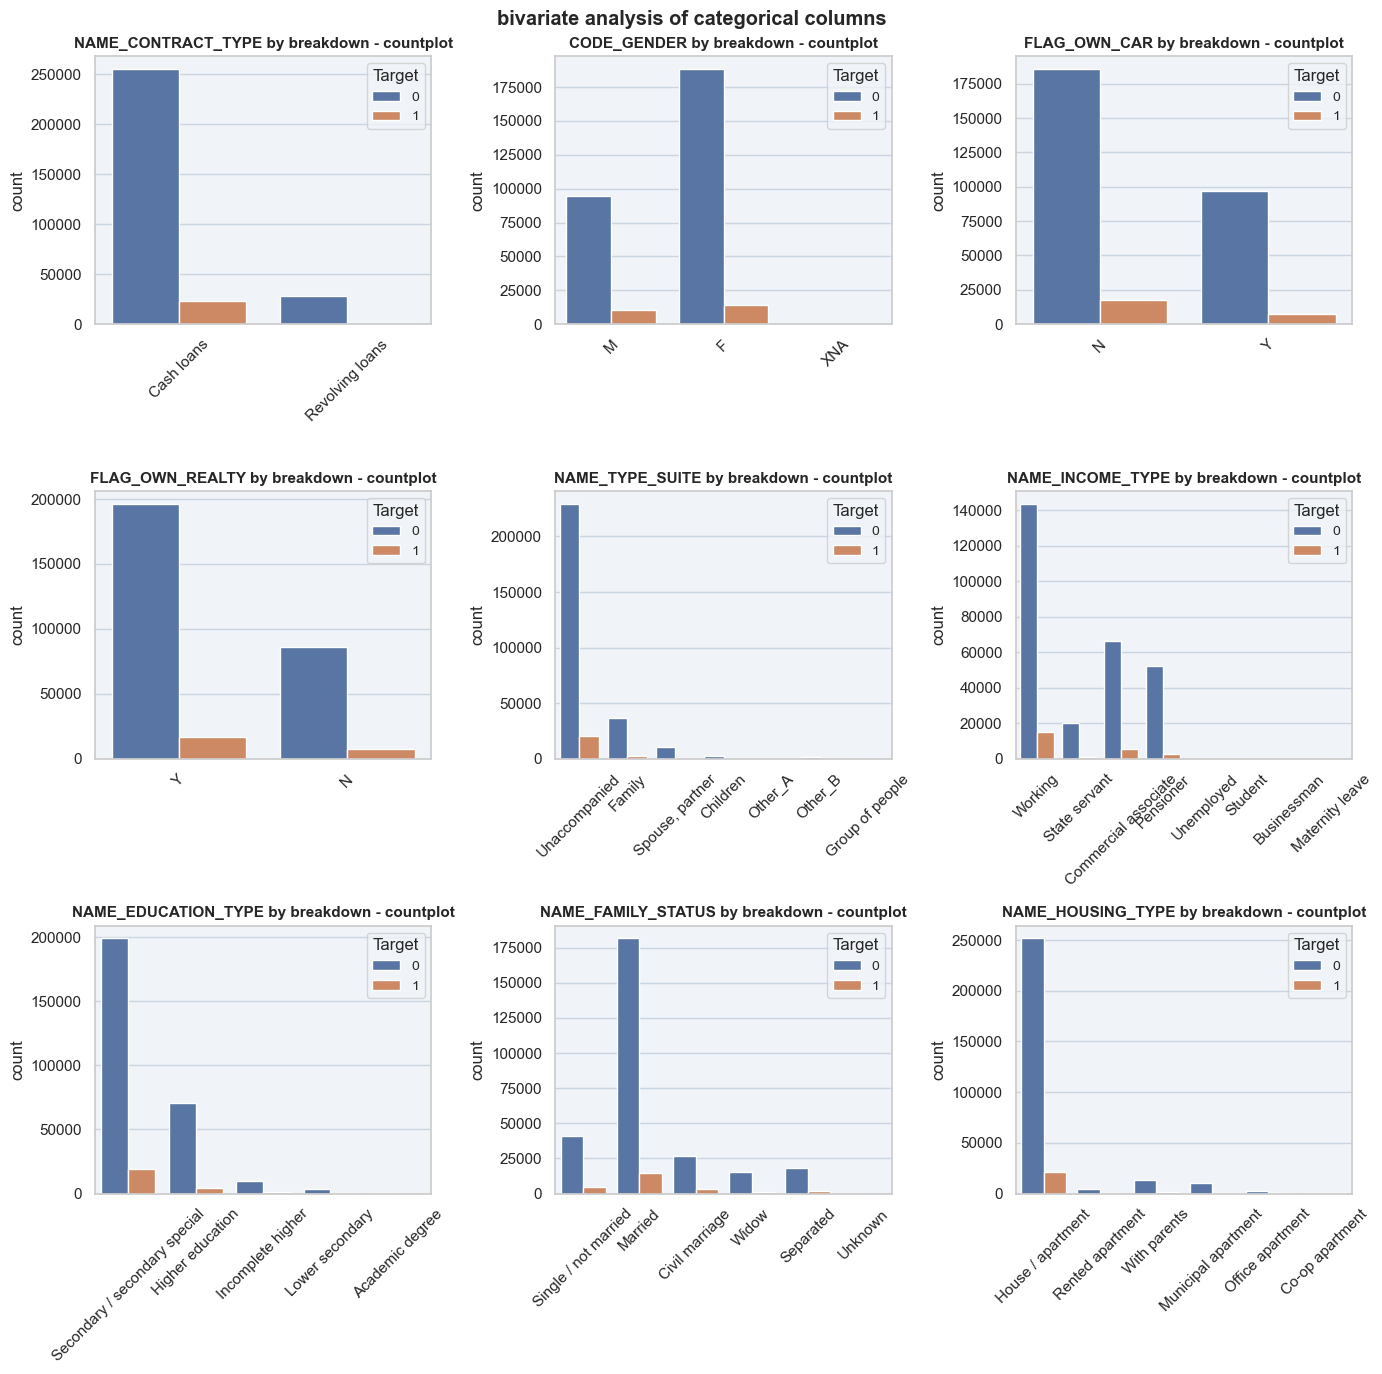

In [ ]:
#bivariate analysis of categorical columns


fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.countplot(data=data_eda, x=col, hue="TARGET", ax=axes[i])
    axes[i].set_title(f"{col} by breakdown - countplot", fontsize=11, weight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(loc="upper right", fontsize="small", title="Target")
    axes[i].set_xlabel("")
    
plt.suptitle("bivariate analysis of categorical columns", weight='bold')
plt.tight_layout()
plt.show()

#### Observation:
Looking at defaulters across categories, the dataset shows a strong class imbalance overall defaulters are a small minority in every group (under 25K in most cases). Contract type shows defaulters almost entirely in "Cash loans," with virtually none in "Revolving loans." For demographics, female applicants show slightly more defaulters than males, though this likely reflects their larger share of the overall dataset rather than higher actual risk. Similarly, applicants without a car, without accompanying family members, married, working, with secondary education, and living in a house/apartment all show the highest defaulter counts but in each case, that same group also has the largest overall count, so the high defaulter numbers are partly just a reflection of group size, not necessarily higher risk. A few groups stand out as potentially meaningful despite smaller counts: "Family" type-suite applicants and "Single/not married" applicants both show a fair number of defaulters relative to their smaller group size, suggesting these groups might carry proportionally higher risk once the count-bias is accounted for. Overall, raw counts alone can be misleading here since they're heavily influenced by how large each group is a percentage-based comparison (default rate per group) would give a clearer, fairer picture of actual risk.

In [49]:
#confirming the observation
for col in cat_col:
    print(f"\n--- {col} ---")
    print(data_eda.groupby(col)['TARGET'].mean().sort_values(ascending=False))


--- NAME_CONTRACT_TYPE ---
NAME_CONTRACT_TYPE
Cash loans         0.083459
Revolving loans    0.054783
Name: TARGET, dtype: float64

--- CODE_GENDER ---
CODE_GENDER
M      0.101419
F      0.069993
XNA    0.000000
Name: TARGET, dtype: float64

--- FLAG_OWN_CAR ---
FLAG_OWN_CAR
N    0.085002
Y    0.072437
Name: TARGET, dtype: float64

--- FLAG_OWN_REALTY ---
FLAG_OWN_REALTY
N    0.083249
Y    0.079616
Name: TARGET, dtype: float64

--- NAME_TYPE_SUITE ---
NAME_TYPE_SUITE
Other_B            0.098305
Other_A            0.087760
Group of people    0.084871
Unaccompanied      0.081687
Spouse, partner    0.078716
Family             0.074946
Children           0.073768
Name: TARGET, dtype: float64

--- NAME_INCOME_TYPE ---
NAME_INCOME_TYPE
Maternity leave         0.400000
Unemployed              0.363636
Working                 0.095885
Commercial associate    0.074843
State servant           0.057550
Pensioner               0.053864
Businessman             0.000000
Student                 0.00

#### Observations : Default Rate by Category (Combined)
Looking at actual default rates instead of raw counts reveals some patterns that were hidden before. Cash loans are riskier than revolving loans (8.3% vs 5.5%). Male applicants default more than females (10.1% vs 7.0%). Not owning a car or realty is slightly riskier than owning them, though the gap is small. The most striking finding is in income type: "Maternity leave" (40%) and "Unemployed" (36%) applicants have extremely high default rates, far higher than the dominant "Working" category (9.6%), this risk was completely hidden in the raw-count chart since these groups are tiny. Education shows a clear, logical trend: default rate decreases as education level increases, from "Lower secondary" (10.9%) down to "Academic degree" (1.8%). Family status shows "Civil marriage" and "Single/not married" as the riskiest (~9.8-9.9%), while "Married" is actually safer (7.6%) than the raw counts suggested. Housing type flips the earlier picture entirely "Rented apartment" (12.3%) and "With parents" (11.7%) are the riskiest groups, while "House/apartment" (which had the highest raw count) is actually one of the safer categories (7.8%)

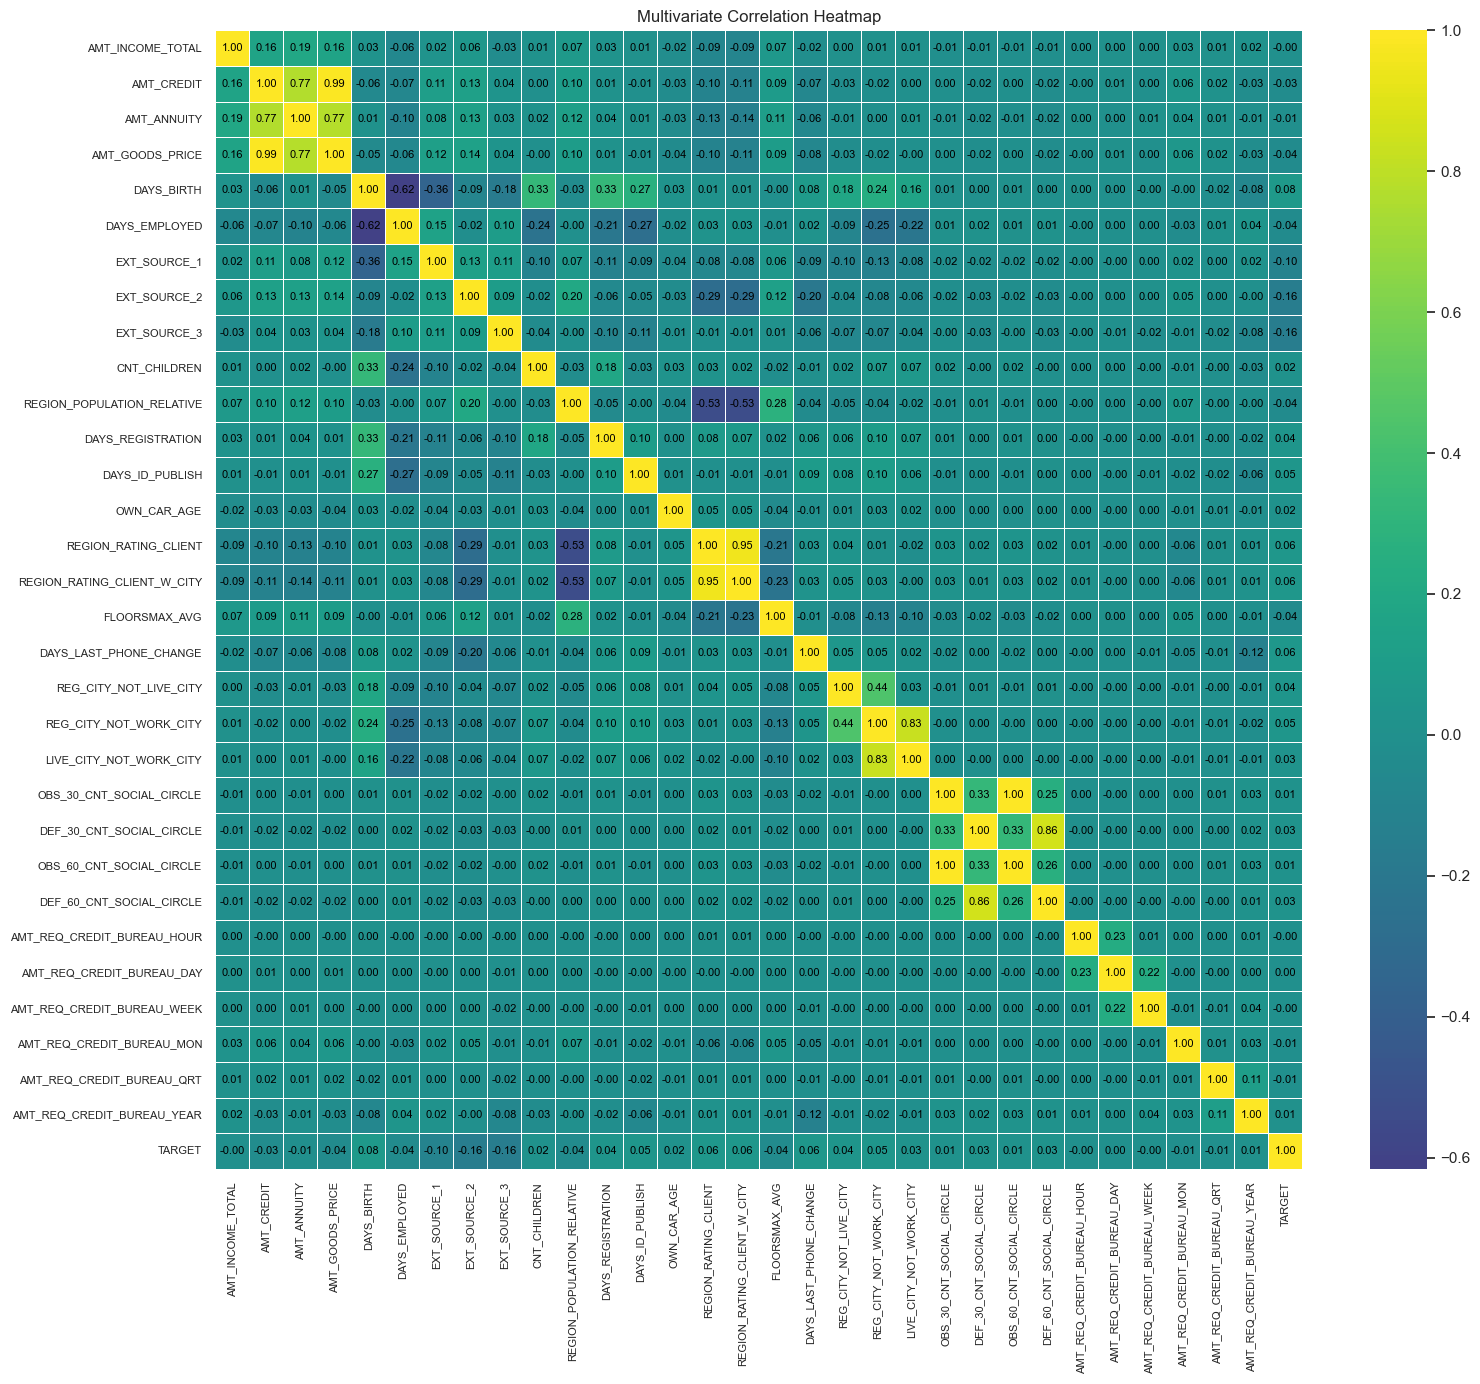

In [50]:
#Multivariate analysis o numerical columns
#Every columns in eda_data df
multivariate_cols = num_col + ['REGION_POPULATION_RELATIVE', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'FLOORSMAX_AVG', 'DAYS_LAST_PHONE_CHANGE', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',  'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',  'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'TARGET' ]

plt.figure(figsize=(16, 14))
corr_matrix = data_eda[multivariate_cols].corr()
sns.heatmap(corr_matrix, cmap='viridis', center=0, annot=True, fmt='.2f', linewidths=0.5, linecolor='white', annot_kws={"color": "black", "size": 8})
plt.xticks(rotation=90)
plt.tick_params(axis='x', labelsize=8)
plt.tick_params(axis='y', labelsize=8)
plt.title("Multivariate Correlation Heatmap")
plt.tight_layout()
plt.show()

In [52]:
print(corr_matrix['TARGET'].sort_values(ascending=False)) 

TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
REG_CITY_NOT_LIVE_CITY         0.044395
DAYS_REGISTRATION              0.041975
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032394
DEF_60_CNT_SOCIAL_CIRCLE       0.031401
CNT_CHILDREN                   0.019187
OWN_CAR_AGE                    0.015982
OBS_30_CNT_SOCIAL_CIRCLE       0.009447
OBS_60_CNT_SOCIAL_CIRCLE       0.009337
AMT_REQ_CREDIT_BUREAU_YEAR     0.005522
AMT_REQ_CREDIT_BUREAU_DAY      0.001701
AMT_REQ_CREDIT_BUREAU_HOUR    -0.000074
AMT_REQ_CREDIT_BUREAU_WEEK    -0.001306
AMT_INCOME_TOTAL              -0.003982
AMT_REQ_CREDIT_BUREAU_QRT     -0.005833
AMT_ANNUITY                   -0.012815
AMT_REQ_CREDIT_BUREAU_MON     -0.014794
AMT_CREDIT                    -0.030369


#### Observation:
Most individual features show weak correlation with TARGET — EXT_SOURCE_2, EXT_SOURCE_3, and EXT_SOURCE_1 remain the strongest predictors, followed by DAYS_BIRTH and DAYS_EMPLOYED. More important than TARGET-correlation here is the multicollinearity found between features themselves: several groups of columns are highly correlated with each other, meaning they carry overlapping/redundant information. Key redundant groups found: (1) AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE (0.77-0.99 with each other), (2) REGION_RATING_CLIENT, REGION_RATING_CLIENT_W_CITY, REGION_POPULATION_RELATIVE (0.50-0.95), (3) REG_CITY_NOT_WORK_CITY, LIVE_CITY_NOT_WORK_CITY, REG_CITY_NOT_LIVE_CITY (0.44-0.83), (4) the four social circle columns (OBS_30, DEF_30, OBS_60, DEF_60) (0.25-0.86 with each other), and (5) the bureau inquiry columns showing mild correlation among themselves (0.11-0.23). DAYS_BIRTH and DAYS_EMPLOYED also show a strong -0.62 correlation with each other, which makes sense (older people tend to have longer employment history).

### FEATURE ENGINEERING

In [53]:
# placeholder error value 365243 in days employeed
data['DAYS_EMPLOYED'] = data['DAYS_EMPLOYED'].replace(365243, np.nan)
data['DAYS_EMPLOYED'] = data['DAYS_EMPLOYED'].fillna(data['DAYS_EMPLOYED'].median())

#Converting DAYS_BIRTH and DAYS_EMPLOYED in readable positive years format
data['AGE_YEARS'] = (-data['DAYS_BIRTH'] / 365).astype(int)
data['EMPLOYED_YEARS'] = (-data['DAYS_EMPLOYED'] / 365)
#now droping
data = data.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'])

#Deleting duplicate columns
data = data.drop(columns=['OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'REGION_RATING_CLIENT'])

# making loan amount ratio than remove redundant columns
data['CREDIT_INCOME_RATIO'] = data['AMT_CREDIT'] / data['AMT_INCOME_TOTAL']
data['ANNUITY_INCOME_RATIO'] = data['AMT_ANNUITY'] / data['AMT_INCOME_TOTAL']
data['CREDIT_GOODS_RATIO'] = data['AMT_CREDIT'] / data['AMT_GOODS_PRICE']
data = data.drop(columns=['AMT_ANNUITY', 'AMT_GOODS_PRICE'])

# combining city mismatch , and then drop raw
data['TOTAL_CITY_MISMATCH'] = (data['REG_CITY_NOT_LIVE_CITY'] + data['REG_CITY_NOT_WORK_CITY'] + data['LIVE_CITY_NOT_WORK_CITY'])
data = data.drop(columns=['REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY'])

#combining Bureau inquiries, and raw drop
bureau_cols = ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY','AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']
data['TOTAL_BUREAU_INQUIRIES'] = data[bureau_cols].sum(axis=1)
data = data.drop(columns=bureau_cols)

#combining contact info from df_reserved, then merge with original data df
df_reserved['TOTAL_CONTACT_INFO'] = (df_reserved['FLAG_EMAIL'] + df_reserved['FLAG_MOBIL'] +  df_reserved['FLAG_PHONE'] + df_reserved['FLAG_WORK_PHONE'] + df_reserved['FLAG_EMP_PHONE'] + df_reserved['FLAG_CONT_MOBILE'])
data = data.merge(df_reserved[['SK_ID_CURR', 'TOTAL_CONTACT_INFO']], on='SK_ID_CURR', how='left')

#combining Document flags- these are already in data
doc_cols = [col for col in data.columns if col.startswith('FLAG_DOCUMENT')]
data['TOTAL_DOCUMENTS_SUBMITTED'] = data[doc_cols].sum(axis=1)
data = data.drop(columns=doc_cols)

#XNA gender fix
data = data[data['CODE_GENDER'] != 'XNA']

print("new shape of data: ", data.shape)
print(data.isnull().sum().sum())
print(data.head())

new shape of data:  (307507, 38)
0
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT NAME_TYPE_SUITE  \
0               Y             0          202500.0    406597.5   Unaccompanied   
1               N             0          270000.0   1293502.5          Family   
2               Y             0           67500.0    135000.0   Unaccompanied   
3               Y             0          135000.0    312682.5   Unaccompanied   
4               Y             0          121500.0    513000.0   Unaccompanied   

   ... DAYS_LAST_PHONE_CHANGE AGE_YEARS EMPLOYED_YEARS CREDIT_I

In [54]:
#Deciding which encoding method suitable for categorical columns
cat_columns = data.select_dtypes(include='object').columns.tolist()
print(cat_columns)
print(len(cat_columns))

for col in cat_columns:
    print(f"{col}: {data[col].nunique()} unique values")

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']
12
NAME_CONTRACT_TYPE: 2 unique values
CODE_GENDER: 2 unique values
FLAG_OWN_CAR: 2 unique values
FLAG_OWN_REALTY: 2 unique values
NAME_TYPE_SUITE: 7 unique values
NAME_INCOME_TYPE: 8 unique values
NAME_EDUCATION_TYPE: 5 unique values
NAME_FAMILY_STATUS: 6 unique values
NAME_HOUSING_TYPE: 6 unique values
OCCUPATION_TYPE: 19 unique values
WEEKDAY_APPR_PROCESS_START: 7 unique values
ORGANIZATION_TYPE: 58 unique values


In [56]:
model_data = data.copy()
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

#apply label encodong in binary columns
binary_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
le = LabelEncoder()
for col in binary_cols:
    model_data[col] = le.fit_transform(model_data[col])

#apply One-Hot Encoding 
nominal_cols = ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 
                'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START']
model_data = pd.get_dummies(model_data, columns=nominal_cols, drop_first=True)

#Ordinal column 
education_order = [['Lower secondary', 'Secondary / secondary special', 'Incomplete higher', 'Higher education', 'Academic degree']]
ord_enc = OrdinalEncoder(categories=education_order)
model_data['NAME_EDUCATION_TYPE'] = ord_enc.fit_transform(model_data[['NAME_EDUCATION_TYPE']])

# 4. High-cardinality columns - Frequency Encoding
for col in ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']:
    freq_map = model_data[col].value_counts().to_dict()
    model_data[col] = model_data[col].map(freq_map)

print("new shape after encoding: ", model_data.shape)
print(model_data.dtypes.value_counts())


new shape after encoding:  (307507, 62)
bool       29
float64    18
int64      15
Name: count, dtype: int64


In [57]:
#spliting data for model
from sklearn.model_selection import train_test_split

X = model_data.drop(columns=['TARGET', 'SK_ID_CURR'])
y = model_data['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(246005, 60) (61502, 60)


In [58]:
# For CatBoost bcz its work best without scalling
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

In [59]:
print(X_train.describe().T[['min', 'max']])

                                      min           max
NAME_CONTRACT_TYPE           0.000000e+00  1.000000e+00
CODE_GENDER                  0.000000e+00  1.000000e+00
FLAG_OWN_CAR                 0.000000e+00  1.000000e+00
FLAG_OWN_REALTY              0.000000e+00  1.000000e+00
CNT_CHILDREN                 0.000000e+00  1.900000e+01
AMT_INCOME_TOTAL             2.565000e+04  1.170000e+08
AMT_CREDIT                   4.500000e+04  4.050000e+06
NAME_EDUCATION_TYPE          0.000000e+00  4.000000e+00
REGION_POPULATION_RELATIVE   2.900000e-04  7.250800e-02
DAYS_REGISTRATION           -2.467200e+04  0.000000e+00
DAYS_ID_PUBLISH             -7.197000e+03  0.000000e+00
OWN_CAR_AGE                  0.000000e+00  9.100000e+01
OCCUPATION_TYPE              5.260000e+02  9.638900e+04
REGION_RATING_CLIENT_W_CITY  1.000000e+00  3.000000e+00
ORGANIZATION_TYPE            2.400000e+01  6.799200e+04
EXT_SOURCE_1                 1.456813e-02  9.626928e-01
EXT_SOURCE_2                 8.173617e-08  8.549

In [60]:
model_data.select_dtypes(include='number').head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,NAME_EDUCATION_TYPE,...,DAYS_LAST_PHONE_CHANGE,AGE_YEARS,EMPLOYED_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,TOTAL_CITY_MISMATCH,TOTAL_BUREAU_INQUIRIES,TOTAL_CONTACT_INFO,TOTAL_DOCUMENTS_SUBMITTED
0,100002,1,0,1,0,1,0,202500.0,406597.5,1.0,...,-1134.0,25,1.745205,2.007889,0.121978,1.158397,0,1.0,4,1
1,100003,0,0,0,0,0,0,270000.0,1293502.5,3.0,...,-828.0,45,3.254795,4.790750,0.132217,1.145199,0,0.0,4,1
2,100004,0,1,1,1,1,0,67500.0,135000.0,1.0,...,-815.0,52,0.616438,2.000000,0.100000,1.000000,0,0.0,5,0
3,100006,0,0,0,0,1,0,135000.0,312682.5,1.0,...,-617.0,52,8.326027,2.316167,0.219900,1.052803,0,0.0,3,1
4,100007,0,0,1,0,1,0,121500.0,513000.0,1.0,...,-1106.0,54,8.323288,4.222222,0.179963,1.000000,2,0.0,3,1


In [ ]:
#Scaling numerical columns
#we are separating columns so which columns have already 2 binary value so we don't scale them
from sklearn.preprocessing import StandardScaler
exclude_from_scaling = []
for col in X_train.columns:
    if X_train[col].nunique() == 2:
        exclude_from_scaling.append(col)
    elif X_train[col].max() <= 10 and X_train[col].min() >= -1:
        exclude_from_scaling.append(col)

cols_to_scale = [col for col in X_train.select_dtypes(include=['float64', 'int64']).columns 
                  if col not in exclude_from_scaling]

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Scaled:", len(cols_to_scale), "columns")
print("Not scaled:", len(exclude_from_scaling), "columns")
print('CREDIT_INCOME_RATIO' in cols_to_scale)

Scaled: 15 columns
Not scaled: 45 columns
True


## Machine Learning

In [62]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56537
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61502
   macro avg       0.56      0.68      0.53     61502
weighted avg       0.90      0.69      0.76     61502

ROC-AUC: 0.746076257915282
Confusion Matrix:
 [[38971 17566]
 [ 1622  3343]]


In [63]:
# Business cost values
cost_FN = 10   #missing defaulter meaning loss o bank pricipal
cost_FP = 1    # mistakenly reject, just lost the opportunity

print(f"FN cost: {cost_FN}, FP cost: {cost_FP}")

FN cost: 10, FP cost: 1


In [64]:
# calculating business cost on every threshold hold
thresholds = np.arange(0.1, 0.95, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = (fn * cost_FN) + (fp * cost_FP)
    results.append({'threshold': t, 'FN': fn, 'FP': fp, 'total_cost': total_cost})

results_df = pd.DataFrame(results)
print(results_df)

    threshold    FN     FP  total_cost
0        0.10    13  55577       55707
1        0.15    51  52913       53423
2        0.20   127  48611       49881
3        0.25   245  43379       45829
4        0.30   420  37762       41962
5        0.35   652  32137       38657
6        0.40   933  26747       36077
7        0.45  1262  21928       34548
8        0.50  1622  17566       33786
9        0.55  2037  13576       33946
10       0.60  2432  10213       34533
11       0.65  2843   7275       35705
12       0.70  3290   4969       37869
13       0.75  3738   3078       40458
14       0.80  4163   1653       43283
15       0.85  4531    678       45988
16       0.90  4817    166       48336


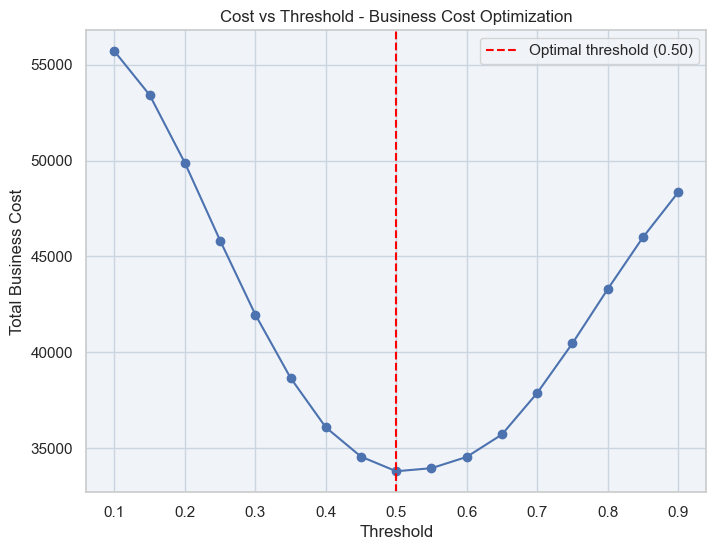

In [66]:
plt.figure(figsize=(8,6))
plt.plot(results_df['threshold'], results_df['total_cost'], marker='o')
plt.axvline(x=0.50, color='red', linestyle='--', label='Optimal threshold (0.50)')
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost')
plt.title('Cost vs Threshold - Business Cost Optimization')
plt.legend()
plt.grid(True)
plt.show()

#### Observation:
Testing thresholds from 0.05 to 0.95 shows a clear U-shaped cost curve. At low thresholds, the model flags almost everyone as a defaulter, so False Negatives are very low but False Positives are extremely high, driving up total cost. As the threshold increases, False Positives drop sharply while False Negatives rise only slowly, causing total cost to decrease steadily. The minimum total cost (33,780) occurs at threshold = 0.50, where FN (1621) and FP (17570) balance out most efficiently given the 10:1 cost weighting. Beyond 0.50, total cost rises again because False Negatives increase faster than False Positives decrease. This confirms that, from a business perspective, 0.50 is the optimal threshold — it minimizes the total cost of misclassification, balancing the high cost of missed defaults against the lower cost of false alarms.

In [67]:
# Catboost model
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, 
                                 class_weights=[1, 10], random_state=42, verbose=100)
cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)
y_pred_proba_cat = cat_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_cat))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_cat))

0:	learn: 0.6863130	total: 296ms	remaining: 1m 28s
100:	learn: 0.5884643	total: 10.8s	remaining: 21.3s
200:	learn: 0.5792245	total: 21.5s	remaining: 10.6s
299:	learn: 0.5714028	total: 31.6s	remaining: 0us
              precision    recall  f1-score   support

           0       0.96      0.74      0.84     56537
           1       0.18      0.64      0.28      4965

    accuracy                           0.74     61502
   macro avg       0.57      0.69      0.56     61502
weighted avg       0.90      0.74      0.79     61502

ROC-AUC: 0.7587059502300634


In [ ]:
#Applying threshold and check business cost
thresholds = np.arange(0.05, 1.0, 0.05)
results_cat = []

for t in thresholds:
    y_pred_t = (y_pred_proba_cat >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = (fn * cost_FN) + (fp * cost_FP)
    results_cat.append({'threshold': round(t,2), 'FN': fn, 'FP': fp, 'total_cost': total_cost})

results_cat_df = pd.DataFrame(results_cat)
print(results_cat_df)

best_row_cat = results_cat_df.loc[results_cat_df['total_cost'].idxmin()]
print(f"\nBest threshold (CatBoost): {best_row_cat['threshold']:.2f}")
print(f"Minimum total cost (CatBoost): {best_row_cat['total_cost']}")

    threshold    FN     FP  total_cost
0        0.05     1  56345       56355
1        0.10    22  54677       54897
2        0.15    76  50659       51419
3        0.20   184  45100       46940
4        0.25   346  39071       42531
5        0.30   542  33244       38664
6        0.35   813  27729       35859
7        0.40  1121  22763       33973
8        0.45  1458  18400       32980
9        0.50  1815  14457       32607
10       0.55  2236  10993       33353
11       0.60  2624   7951       34191
12       0.65  3059   5488       36078
13       0.70  3506   3530       38590
14       0.75  3938   2012       41392
15       0.80  4351    910       44420
16       0.85  4682    307       47127
17       0.90  4898     50       49030
18       0.95  4963      0       49630

Best threshold (CatBoost): 0.50
Minimum total cost (CatBoost): 32607.0


#### Observation: 
Comparing both models at their optimal thresholds, CatBoost achieves a lower total 
business cost (32,607) than Logistic Regression (33,780), making it the better model 
for this task. Both models show the same optimal threshold of 0.50, meaning the 
standard classification threshold already aligns with the business-cost-minimizing 
point for this dataset and cost ratio (FN:FP = 10:1). CatBoost is therefore the 
recommended model — it not only has better overall discrimination (ROC-AUC 0.758 vs 
0.746) but also results in real financial savings for the business when deployed 
at the optimal threshold.

## Final Summary Task 3: Loan Default Risk with Business Cost Optimization

We started with a 122-column Home Credit dataset, and our first focus was **reducing columns intelligently** — not randomly dropping them, but verifying every decision using missing %, correlation, and domain logic. We removed redundant columns (like `_MODE`/`_MEDI` variants and duplicate region ratings), and set aside weak-but-potentially-useful columns (phone/email flags, region-mismatch flags) in a separate dataframe (`df_reserved`) so they could be reused later in feature engineering instead of being permanently lost.

On the remaining columns, we created a dedicated EDA dataframe (`data_eda`), excluding sparse/low-value columns (like FLAG_DOCUMENT flags) so visualization stayed focused and efficient. We performed **Univariate analysis** (distribution of each column), **Bivariate analysis** (each column's relationship with TARGET), and **Multivariate analysis** (a correlation heatmap showing relationships between columns, including checking the reserved columns) to identify multicollinearity and decide what to combine.

Based on these insights, we did **Feature Engineering**: fixed a known bug in `DAYS_EMPLOYED`, converted birth/employment days into readable years, turned highly correlated columns (like AMT_CREDIT/GOODS_PRICE) into meaningful ratios, and combined the reserved, document, bureau, and social-circle columns into summary features making the dataset more compact and information-rich.

Next, we performed **Encoding** (binary columns → Label Encoding, nominal categories → One-Hot Encoding, ordered categories → manual Ordinal Encoding, high-cardinality columns → Frequency Encoding) and **Scaling** (applied only to continuous columns, skipping binary/already-normalized ones, and done after the train-test split to avoid data leakage).

Finally, we trained both **Logistic Regression and CatBoost**, and instead of stopping at accuracy, we optimized the decision **threshold based on business cost** (setting False Negative cost 10x higher than False Positive cost, since missing a default is far more costly to the bank than a false alarm). Both models had an optimal threshold of 0.50, and **CatBoost** delivered the lower total cost (32,607 vs 33,780), making it the recommended final model.